# Module 05 — Regression: predicting numbers

*Can you weigh a penguin with a ruler?*

Back to Palmer Station, Antarctica. Between 2007 and 2009, biologists of the Palmer Long-Term Ecological Research program measured 344 Adélie, Chinstrap, and Gentoo penguins — the same dataset you cleaned in Module 02 and classified in Module 04.

This time the question is different. Module 04 asked *"which species?"* — a **classification** question, answered with a category. Today we ask *"how much does this penguin weigh?"* — a **regression** question, answered with a number. Weighing a wild penguin means catching it, which stresses the bird and eats a field day. But flipper length can be measured from a photo. The study of how one body measurement predicts another is called **allometry**, and it's a real biological discipline — mass-from-photo estimates are published for whales, elephant seals, and yes, penguins.

Run each cell in order; predict before you run. Every non-obvious line has a `#` comment explaining it.

In [1]:
import numpy as np                # arrays (Module 01)
import pandas as pd               # tables (Module 02)
import matplotlib.pyplot as plt   # drawing plots
import seaborn as sns             # nicer-looking plots

sns.set_theme(style="whitegrid", palette="colorblind")

# One fixed color per species, same as Modules 02 and 04.
palette = sns.color_palette("colorblind")
SPECIES_COLORS = {"Adelie": palette[0], "Chinstrap": palette[1], "Gentoo": palette[2]}

## 1. Load and re-clean the penguins

Same dataset, same cleaning decision as Module 02: drop the 11 incomplete rows (we'll be using the measurements *and* sex, and the loss is tiny).

In [2]:
from datasets import load_dataset   # the HuggingFace downloader

# Download, convert to a pandas table, drop rows with missing values -- all in
# the same three steps as Module 02.
raw = load_dataset("SIH/palmer-penguins", split="train").to_pandas()
df = raw.dropna()   # a new table without the incomplete rows

print(f"kept {len(df)} of {len(raw)} penguins")
df.head()

kept 333 of 344 penguins


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


## 2. The question, as a picture

Before any model: *look*. Does flipper length even carry information about body mass? One scatter plot answers that.

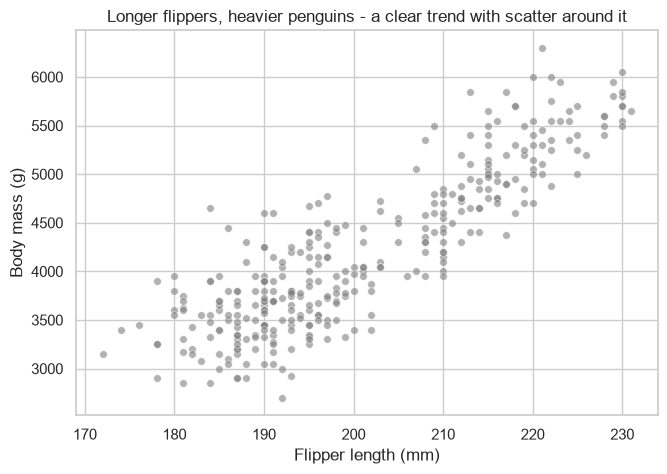

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 5))

# Plain gray dots this time -- today's question is about the overall trend,
# not the species clusters (those return in the exercises).
ax.scatter(df["flipper_length_mm"], df["body_mass_g"],
           s=30, color="gray", alpha=0.6, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Body mass (g)")
ax.set_title("Longer flippers, heavier penguins - a clear trend with scatter around it")
plt.show()

A strong upward trend — but not a perfect one: penguins with the *same* flipper length differ by 1,000 g or more. A model can capture the trend; the scatter around it is what the model will get wrong. Both halves matter.

## 3. Split first, always

Quick recap from Module 04: if we grade the model on the same penguins it learned from, we can't tell learning apart from memorizing — like a student grading themselves on the answer key they studied. So before *any* fitting, we lock part of the data away as the **test set**.

Notation reminder:

- `X` = the **features** (the measurements the model may look at). scikit-learn wants `X` as a *table*, even when there's only one column — that's why the double brackets `[[...]]` below.
- `y` = the **label** (the value to predict — here, a number: body mass).

In [4]:
from sklearn.model_selection import train_test_split   # the splitter (Module 04)

X = df[["flipper_length_mm"]]   # features: a one-column TABLE (note the [[ ]])
y = df["body_mass_g"]           # label: the number we want to predict

# Randomly set aside 25% of penguins as the test set (the default).
# random_state=42 fixes the shuffle so everyone gets the same split.
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

print("training penguins:", len(X_train))
print("test penguins:    ", len(X_test))

training penguins: 249
test penguins:     84


## 4. Fit a line and read it like a biologist

`LinearRegression` finds the single straight line through the training points whose total (squared) vertical error is smallest — the classic "least squares" line, the same one biology papers have fit for a century.

The recipe is exactly Module 04's: make the model, `.fit(X_train, y_train)`, done. Only the model type changed.

In [5]:
from sklearn.linear_model import LinearRegression   # the straight-line model

line_model = LinearRegression()        # make an (untrained) model
line_model.fit(X_train, y_train)       # learn the best line from the TRAINING penguins only

# A fitted line is just two numbers:
# .coef_ holds one slope per feature (we have 1 feature, so we take item [0]);
# .intercept_ is where the line crosses flipper = 0.
slope = line_model.coef_[0]
intercept = line_model.intercept_

print(f"slope:     {round(slope, 1)} grams per mm of flipper")
print(f"intercept: {round(intercept)} grams")

slope:     50.0 grams per mm of flipper
intercept: -5849 grams


Read those two numbers like a biologist:

- **Slope ≈ 50 g/mm** — the exchange rate. Two penguins whose flippers differ by 10 mm should differ in mass by about 500 g. *This* is the allometry result.
- **Intercept ≈ −5,849 g** — where the line would cross flipper = 0 mm. A flipperless penguin with negative mass does not exist; the intercept just anchors the line's height. Slopes usually mean something biological; intercepts often don't.

The whole model is one formula: `mass ≈ 50 × flipper − 5849`. Let's draw it over the data.

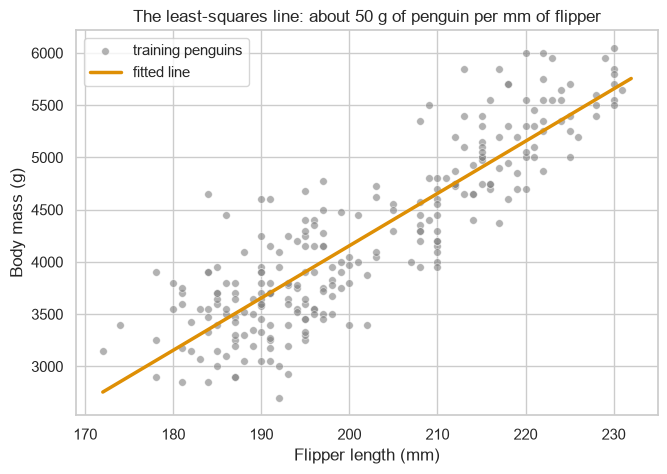

In [6]:
# To draw the line we ask the model to predict mass at many flipper lengths.
# np.linspace(start, stop, n) makes n evenly spaced values between start and stop.
grid = pd.DataFrame({"flipper_length_mm": np.linspace(172, 232, 100)})

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(X_train["flipper_length_mm"], y_train,
           s=30, color="gray", alpha=0.6, edgecolor="white", linewidth=0.5,
           label="training penguins")
# .predict(grid) returns the line's mass estimate for each flipper value in grid.
ax.plot(grid["flipper_length_mm"], line_model.predict(grid),
        color=palette[1], linewidth=2.5, label="fitted line")
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Body mass (g)")
ax.set_title("The least-squares line: about 50 g of penguin per mm of flipper")
ax.legend()
plt.show()

In [7]:
# The payoff: estimate the mass of a NEW penguin from a photo measurement.
# The model expects a table with the same column name it was trained on.
new_penguin = pd.DataFrame({"flipper_length_mm": [201]})

estimate = line_model.predict(new_penguin)[0]   # predict returns an array; [0] = first entry
print(f"a penguin with a 201 mm flipper is estimated at {round(estimate)} g")

a penguin with a 201 mm flipper is estimated at 4205 g


## 5. Residuals — what the line gets wrong

No penguin sits exactly on the line. Each penguin's **residual** is the vertical gap between it and the line:

```
residual = actual mass − predicted mass
```

Positive residual → heavier than its flipper suggests (a well-fed bird). Negative → lighter. Let's *see* the residuals as vertical segments — 30 random training penguins keep the picture readable.

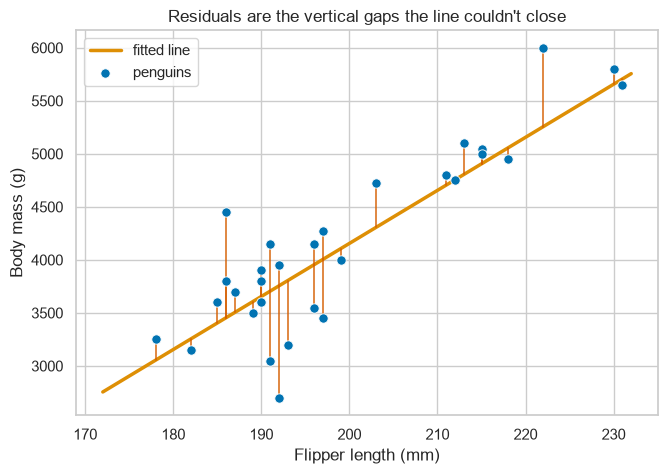

In [8]:
# .sample(n=30) picks 30 random rows; random_state fixes WHICH 30.
demo = X_train.copy()                    # copy so we don't modify X_train itself
demo["body_mass_g"] = y_train            # put the true masses back next to the flippers
demo = demo.sample(n=30, random_state=42)

# The model's prediction for each of the 30 penguins:
demo_pred = line_model.predict(demo[["flipper_length_mm"]])

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(grid["flipper_length_mm"], line_model.predict(grid),
        color=palette[1], linewidth=2.5, label="fitted line")

# One vertical red segment per penguin: from its prediction up/down to its true mass.
for i in range(len(demo)):
    flip = demo["flipper_length_mm"].iloc[i]    # .iloc[i] = row number i (Module 02)
    ax.plot([flip, flip],                       # same x twice -> a vertical segment
            [demo_pred[i], demo["body_mass_g"].iloc[i]],
            color=palette[3], linewidth=1.3, alpha=0.8)

ax.scatter(demo["flipper_length_mm"], demo["body_mass_g"],
           s=45, color=palette[0], edgecolor="white", linewidth=0.6,
           label="penguins", zorder=3)   # zorder=3 draws the dots on top
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Body mass (g)")
ax.set_title("Residuals are the vertical gaps the line couldn't close")
ax.legend()
plt.show()

Scientists stare at residuals the way you'd stare at a gel that ran funny: the *pattern* of the errors is diagnostic. The standard tool is the **residual plot** — residuals on the y-axis, with a line at zero:

- a shapeless, even cloud around zero → the model captured the trend; what's left is noise;
- a curve, a fan, or a group sitting consistently off to one side → the model is *systematically* missing something, often a lurking variable.

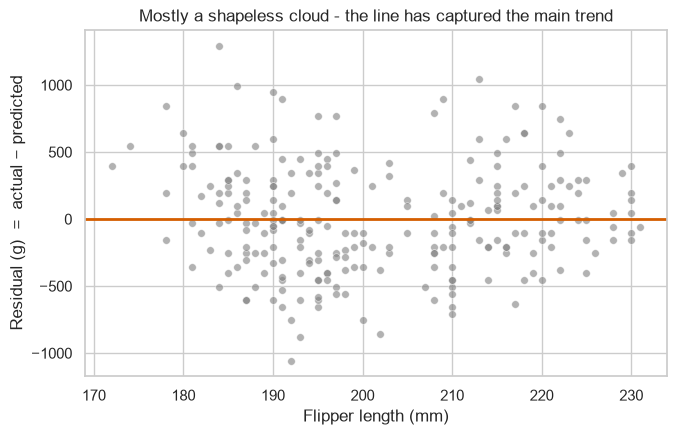

average residual: 0.0 g  (least squares always balances to ~0)


In [9]:
# Residuals for ALL training penguins: actual minus predicted.
train_pred = line_model.predict(X_train)
residuals = y_train - train_pred

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.scatter(X_train["flipper_length_mm"], residuals,
           s=30, color="gray", alpha=0.6, edgecolor="white", linewidth=0.5)
ax.axhline(0, color=palette[3], linewidth=2)   # axhline draws a horizontal line at y=0
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Residual (g)  =  actual − predicted")
ax.set_title("Mostly a shapeless cloud - the line has captured the main trend")
plt.show()

print(f"average residual: {round(residuals.mean(), 6)} g  (least squares always balances to ~0)")

Mostly shapeless — but not entirely. Exercise 3 has you color this plot by species, and one species turns out to sit consistently below the line. The residuals know something the model doesn't.

## 6. Scoring the model: MAE, RMSE, R²

Eyeballing is good; numbers let us compare models. All three scores are computed on the **test set** — the penguins the model has never seen:

- **MAE** (mean absolute error): the average size of the mistakes, in grams. The most honest, interpretable number.
- **RMSE** (root mean squared error): like MAE, but errors are squared before averaging (then un-squared at the end), so big misses are punished extra hard. Always ≥ MAE.
- **R²** ("R squared"): the fraction of the mass variation the model explains. 0 = no better than always guessing the average penguin; 1 = perfect.

In [10]:
# scikit-learn provides one function per score; each takes (true values, predictions).
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

test_pred = line_model.predict(X_test)   # predictions for the held-out penguins

mae = mean_absolute_error(y_test, test_pred)
rmse = root_mean_squared_error(y_test, test_pred)
r2 = r2_score(y_test, test_pred)

print(f"MAE:  {round(mae)} g   (typical mistake)")
print(f"RMSE: {round(rmse)} g   (big misses weighted extra)")
print(f"R^2:  {round(r2, 2)}    (fraction of mass variation explained)")

MAE:  290 g   (typical mistake)
RMSE: 371 g   (big misses weighted extra)
R^2:  0.76    (fraction of mass variation explained)


In [11]:
# How good is 290 g, really? Compare against the dumbest possible model:
# ALWAYS predict the average training mass, ignoring the flipper entirely.
# np.full(n, value) builds an array of n copies of value.
always_average = np.full(len(y_test), y_train.mean())

print(f"guessing the average every time: MAE = {round(mean_absolute_error(y_test, always_average))} g")
print(f"using the flipper:               MAE = {round(mae)} g")

guessing the average every time: MAE = 643 g
using the flipper:               MAE = 290 g


One photo-friendly measurement cuts the typical error from ~640 g to ~290 g and explains about three-quarters of the variation in penguin mass (R² ≈ 0.76). That's a genuinely publishable allometry result from four lines of code.

## 7. Multiple regression — more measurements, read with caution

A field biologist wouldn't stop at one measurement. **Multiple regression** is the same `LinearRegression` fed several feature columns at once; it finds the best slope (now called a **coefficient**) *for each feature simultaneously*.

One wrinkle: `sex` is text (`'male'`/`'female'`), and models need numbers. The `.map(...)` method converts a column by looking each value up in a dictionary — `male` becomes 1, `female` becomes 0.

In [12]:
# .map takes a dictionary and replaces each value with its dictionary entry.
df = df.copy()   # fresh copy before adding a column (good pandas hygiene, Module 02)
df["sex_num"] = df["sex"].map({"male": 1, "female": 0})

# Four features this time. X_multi is a 4-column table.
feature_names = ["flipper_length_mm", "bill_length_mm", "bill_depth_mm", "sex_num"]
X_multi = df[feature_names]

# Same split as before (random_state=42 -> the SAME penguins land in train/test,
# so the comparison with the flipper-only model is fair).
Xm_train, Xm_test, ym_train, ym_test = train_test_split(X_multi, y, random_state=42)

multi_model = LinearRegression()
multi_model.fit(Xm_train, ym_train)

multi_mae = mean_absolute_error(ym_test, multi_model.predict(Xm_test))
multi_r2 = r2_score(ym_test, multi_model.predict(Xm_test))

print(f"flipper only:      test MAE = {round(mae)} g,  R^2 = {round(r2, 2)}")
print(f"four measurements: test MAE = {round(multi_mae)} g,  R^2 = {round(multi_r2, 2)}")

flipper only:      test MAE = 290 g,  R^2 = 0.76
four measurements: test MAE = 276 g,  R^2 = 0.79


In [13]:
# One coefficient per feature. A plain loop pairs each name with its slope.
print("coefficient for each feature (grams per unit):")
for i in range(len(feature_names)):
    print(f"  {feature_names[i]:<20} {round(multi_model.coef_[i], 1)}")
    # :<20 just pads the name to 20 characters so the numbers line up.

coefficient for each feature (grams per unit):
  flipper_length_mm    36.9
  bill_length_mm       2.9
  bill_depth_mm        -88.0
  sex_num              563.7


Prediction improved — a typical mistake drops by roughly 15 g and R² nudges up. But now look at those coefficients with a biologist's skepticism:

- **`sex_num` ≈ +560 g**: holding body measurements fixed, males run about 560 g heavier. Credible — that's the sexual dimorphism you quantified in Module 02.
- **`bill_depth_mm` ≈ −88 g/mm**: *deeper bill, lighter penguin?!* Biological nonsense — until you remember Module 02: Gentoos are both the **heaviest** species and the **shallow-billed** one. Inside this mixed-species dataset, a shallow bill is secretly a Gentoo badge, so the model uses bill depth as a backwards species detector.
- The flipper coefficient fell from ~50 to ~37 g/mm, because the other features now absorb part of the size signal.

The moral: each coefficient means "the effect of this feature *with the others held fixed, in this dataset*" — not "the effect of this feature in nature." Multiple regression is a fine predictor and a treacherous storyteller. (Untangling correlation from causation takes designed experiments — which you know all about from biology.)

## 8. The overfitting demo

A straight line is rigid. **`PolynomialFeatures`** lets a linear model bend: degree 3 hands the model flipper, flipper², and flipper³ as extra columns, and the fitted "line" becomes a curve. Degree 12 makes it flexible enough to wiggle through almost anything.

Is flexible better? To find out we make life hard for the model: only **25 training penguins** (small samples are where overfitting bites — every field biologist with a small pilot study should feel a chill here).

Two helpers, then the experiment:

- **`StandardScaler`** (Module 04) rescales flipper lengths to small numbers around 0 first — otherwise 200¹² creates astronomically large columns that break the math.
- **`make_pipeline(A, B, C)`** chains steps into one model: data flows through A, then B, then C. One `.fit`, one `.predict`, no bookkeeping.

In [14]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 25 random TRAINING penguins (never touch the test set for training!).
small = X_train.copy()
small["body_mass_g"] = y_train
small = small.sample(n=25, random_state=42)

small_X = small[["flipper_length_mm"]]   # the tiny training features
small_y = small["body_mass_g"]           # the tiny training labels

degrees = [1, 3, 12]
poly_models = []   # we'll keep each fitted model for plotting

print("degree   train MAE   test MAE")
for degree in degrees:
    # The conveyor belt: rescale -> add polynomial columns -> fit a linear model.
    poly_model = make_pipeline(StandardScaler(),
                               PolynomialFeatures(degree),
                               LinearRegression())
    poly_model.fit(small_X, small_y)          # trained on just 25 penguins
    poly_models.append(poly_model)            # save it for the plot below

    train_mae = mean_absolute_error(small_y, poly_model.predict(small_X))
    test_mae = mean_absolute_error(y_test, poly_model.predict(X_test))
    print(f"{degree:>6}   {round(train_mae):>9}   {round(test_mae):>8}")
    # :>6 pads the number to 6 characters, right-aligned, so columns line up.

degree   train MAE   test MAE
     1         313        296
     3         316        280
    12         246        718


Read the table **before** the plot. Degree 12 has the *best* training error by far — and a test error more than twice as bad as the humble straight line. Now look at what it actually learned:

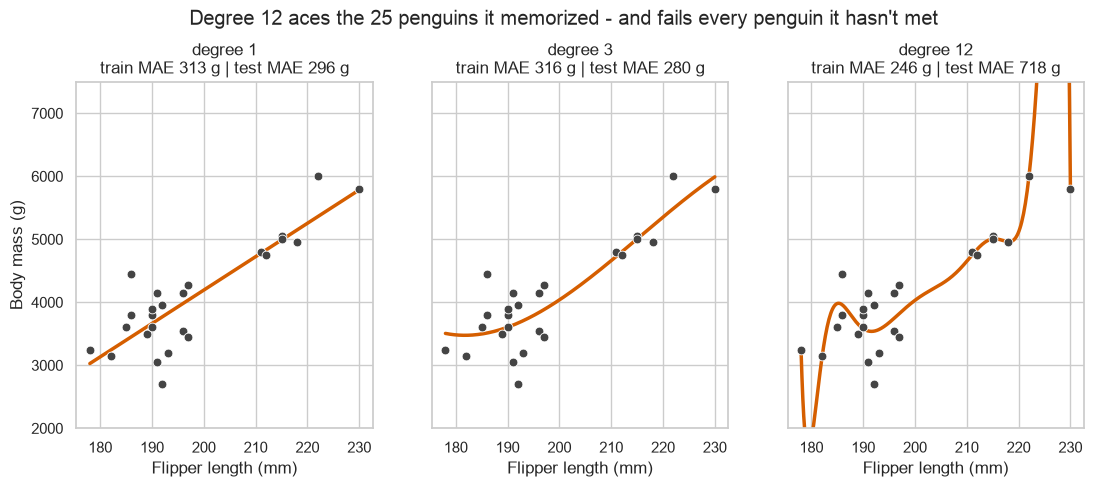

In [15]:
# A smooth x-axis covering just the range of the 25 training penguins.
small_grid = pd.DataFrame({"flipper_length_mm":
                           np.linspace(small_X["flipper_length_mm"].min(),
                                       small_X["flipper_length_mm"].max(), 300)})

# Three side-by-side panels sharing one y-axis.
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)

for i in range(3):
    ax = axes[i]   # panel number i
    ax.scatter(small_X["flipper_length_mm"], small_y,
               s=40, color="#444444", edgecolor="white", linewidth=0.6, zorder=3)
    ax.plot(small_grid["flipper_length_mm"], poly_models[i].predict(small_grid),
            color=palette[3], linewidth=2.5)
    train_mae = mean_absolute_error(small_y, poly_models[i].predict(small_X))
    test_mae = mean_absolute_error(y_test, poly_models[i].predict(X_test))
    ax.set_title(f"degree {degrees[i]}\ntrain MAE {round(train_mae)} g | test MAE {round(test_mae)} g")
    ax.set_xlabel("Flipper length (mm)")
    ax.set_ylim(2000, 7500)   # clip the y-axis: degree 12 shoots far off-scale

axes[0].set_ylabel("Body mass (g)")
fig.suptitle("Degree 12 aces the 25 penguins it memorized - and fails every penguin it hasn't met",
             y=1.04)
plt.show()

Degrees 1 and 3 draw nearly the same sensible curve — the flipper–mass relationship really is close to a straight line, so extra flexibility had nothing useful to do. Degree 12 spent its flexibility chasing the measurement noise of 25 individual penguins: it threads beautifully between *those* points and lurches wildly everywhere else.

This is **overfitting**: the model traded understanding for memorization, like a student who memorized last year's answer key — typos included — instead of learning the biology. And notice what caught it: not the training error (which only ever flatters a flexible model) but the **test set**. This is *why* Module 04 made you split first.

## Recap

| Idea | Code |
|---|---|
| Fit a line | `LinearRegression().fit(X_train, y_train)` |
| Read the line | `model.coef_`, `model.intercept_` |
| Predict for new data | `model.predict(new_table)` |
| Residual | `actual - predicted` (plot them; structure = missing variable) |
| Error in real units | `mean_absolute_error`, `root_mean_squared_error` |
| Variation explained | `r2_score` (0 = guessing the mean, 1 = perfect) |
| Encode a 2-value category | `df["sex"].map({"male": 1, "female": 0})` |
| Bendy linear model | `make_pipeline(StandardScaler(), PolynomialFeatures(d), LinearRegression())` |

> **A model that fits the training data perfectly has often just memorized it.** Module 07 builds a whole workflow around catching this.

Next: [exercises.md](exercises.md). The Challenge has you draw the most famous diagram in machine learning — from these same penguins.